# LoRA 低秩微调

> 清洗后的数据可以训练出通用基座模型，面向具体任务时还需要用更小的数据继续调整参数。7B 模型进行全量微调仅固定训练状态就需要约 112 GB 显存；LoRA 保留基座权重 $W_0$ 不变，只训练低秩更新量 $\Delta W = BA$，从而减少需要保存梯度和优化器状态的参数。
>
> **低秩结构**：$A$ 先把输入压缩到较小的 rank，$B$ 再投影回输出维度，两者共同近似完整的权重更新。
>
> **适配器生命周期**：选择目标 Linear 层，注入 LoRA 旁路，冻结基座参数，训练适配器，最后按需要合并或单独保存。
>
> **架构差异**：dense 模型主要选择 Attention 与 FFN 投影层；MoE 还要区分专家权重和 Router；QLoRA 则进一步量化冻结的基座权重。

全量微调会把权重从 $W_0$ 更新为 $W_1$，真正由新任务学到的变化可以写成 $\Delta W = W_1-W_0$。对于一个 $4096\times4096$ 的 Linear 层，完整保存这份更新需要约 1678 万个数。

如果 $\Delta W$ 可以写成两个较窄矩阵的乘积 $BA$，并令 rank $r=8$，需要训练的数值就变为 $4096\times8+8\times4096=65,536$ 个。基座权重仍然保留，优化器只需要维护这两个小矩阵。

这种用低秩乘积表示权重更新的方法称为 **LoRA**。下面从 $\Delta W$ 的含义开始，观察低秩结构为什么能够减少可训练参数。

## 0. 先建立直觉：微调改出来的 ΔW 是低秩的

先定义这一章最重要的记号：**权重更新量 ΔW**。

全量微调时，每个线性层的权重从预训练值 $W_0$ 变成微调后的 $W_1$，两者之差 $\Delta W = W_1 - W_0$ 就是这次微调学到的全部东西。模型会做新任务，不是结构变了，而是每个权重矩阵都往某个方向移动了一点。

那么，ΔW 的「信息量」有多大？如果它是一个满秩矩阵，每个元素都携带独立信息，就只能把每个元素都存下来。但如果它的信息集中在少数几个方向上，由少数几个「基矩阵」叠加就能拼出来，那就只需要存那几个基。

数学上这个性质叫**低秩**（low-rank）：一个矩阵如果能写成两个小矩阵的乘积 $BA$（$B$ 是 $d_{out} \times r$，$A$ 是 $r \times d_{in}$，$r$ 远小于 $d$），就说它的秩不超过 $r$。

LoRA 的核心假设只有一句话：微调产生的 ΔW 是低秩的。

In [1]:
# 本章所有 import 集中放在第一个 code cell
import copy
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(42)
print("本章两条主线：dense 基座和 MoE 基座各做一次 LoRA 微调。")
print("所有关键结论都用 assert 或打印验证，不只靠文字描述。")

本章两条主线：dense 基座和 MoE 基座各做一次 LoRA 微调。
所有关键结论都用 assert 或打印验证，不只靠文字描述。


In [2]:
# 低秩演示：一个 4x4 的矩阵看起来要存 16 个数，其实 8 个即可
u = torch.tensor([[1.0], [2.0], [3.0], [0.5]])    # 4x1 列向量
v = torch.tensor([[2.0, -1.0, 0.5, 3.0]])         # 1x4 行向量
M1 = u @ v                                        # 外积：4x4，但秩只有 1

print("u @ v 得到的矩阵：")
print(M1)
print()
print("矩阵的秩 =", torch.linalg.matrix_rank(M1).item())
print("矩阵元素个数 =", M1.numel())
print("还原它需要的参数 =", u.numel() + v.numel())
print()
print("关键观察：每一行都是 v 的不同倍数，四行共享同一个模式。")
print("只存 u 和 v 就能还原整个矩阵，这就是低秩的含义。")

# 秩为 2 的矩阵 = 两个外积相加
u2 = torch.tensor([[0.3], [-1.0], [0.8], [0.2]])
v2 = torch.tensor([[1.0, 0.5, -2.0, 0.7]])
M2 = u @ v + u2 @ v2
print()
print("两个外积相加的矩阵，秩 =", torch.linalg.matrix_rank(M2).item())
print("LoRA 的乘积 BA 正是这种叠加：r 越大，能叠加的模式越多。")

u @ v 得到的矩阵：
tensor([[ 2.0000, -1.0000,  0.5000,  3.0000],
        [ 4.0000, -2.0000,  1.0000,  6.0000],
        [ 6.0000, -3.0000,  1.5000,  9.0000],
        [ 1.0000, -0.5000,  0.2500,  1.5000]])

矩阵的秩 = 1
矩阵元素个数 = 16
还原它需要的参数 = 8

关键观察：每一行都是 v 的不同倍数，四行共享同一个模式。
只存 u 和 v 就能还原整个矩阵，这就是低秩的含义。

两个外积相加的矩阵，秩 = 2
LoRA 的乘积 BA 正是这种叠加：r 越大，能叠加的模式越多。


那微调学出来的 ΔW 真的是低秩的吗？有两个实验证据。

第一条来自 2020 年的「内在维度」研究（Aghajanyan et al.）：微调 GPT-2 时，把参数更新限制在一个几百到几千维的子空间里，效果已经接近全参数微调。也就是说，下游任务本身只要求权重在少数方向上变化。

第二条来自 LoRA 论文自己的测量：GPT-3 微调后各层的 ΔW 奇异值谱衰减得很快，能量集中在排前头的几个方向上。这个结果也符合直觉：预训练已经装好了语法、常识和通用推理，微调一个对话任务不需要每行每列都改，只需要调整模型对少数几类输入的反应，不需要改写整个权重矩阵。

LoRA 据此做了一个直接的设计：既然 ΔW 低秩，就让优化器直接学两个小矩阵 $A$ 和 $B$，用乘积 $BA$ 表示 ΔW。

## 1. 全量微调的显存账：冻结到底省了什么

分布式一节算过：AdamW + 混合精度下，每个可训练参数要占用 16 bytes 显存。具体构成是：

| 组成 | 精度 | 每参数字节 |
|:--|:--|:--|
| 权重 | FP16 | 2 |
| 梯度 | FP16 | 2 |
| Adam 的一阶矩 m | FP32 | 4 |
| Adam 的二阶矩 v | FP32 | 4 |
| 主权重 master weights | FP32 | 4 |

其中开销最大的不是权重，而是梯度和优化器状态：只要参数参与训练，这两部分合计每参数 14 bytes。

LoRA 省显存的做法就是利用这一点：冻结的参数只参与前向，权重那 2 bytes 照付，梯度和优化器状态那 14 bytes 不再需要。可训练参数从几十亿降到百万级，优化器状态也就从几百 GB 降到几十到几百 MB。

MoE 模型的这笔账更大。MoE 一节讲过，Mixtral 8x7B 总参数约 47B，其中专家占绝大部分；全量微调时每个专家参数都要配 16 bytes，光固定开销就超过 700 GB。冻结它们，收益比 dense 模型大得多。

In [3]:
# 把这笔账算成具体数字：dense vs MoE，全量 vs LoRA vs QLoRA
def training_memory(name, total_params, trainable_params, frozen_bytes=2):
    """估算训练时的固定显存开销（不含激活值）

    参数:
        name: 方案名
        total_params: 模型总参数量
        trainable_params: 可训练参数量，其余全部冻结
        frozen_bytes: 冻结参数的存储精度，FP16 是 2，QLoRA 的 NF4 是 0.5
    """
    frozen = total_params - trainable_params
    # 冻结部分只存权重；可训练部分权重+梯度+m+v+主权重合计 16 bytes
    total_bytes = frozen * frozen_bytes + trainable_params * 16
    print(f"{name:24s} {total_bytes / 1e9:8.1f} GB")
    return total_bytes


dense_7b = 7e9
moe_47b = 47e9                 # Mixtral 8x7B 总参数
dense_lora_ratio = 0.004       # all-linear、r=16 时可训练参数占比，量级参考
moe_lora_ratio = 0.002         # MoE 分母更大，占比更低

print("=== 训练显存估算（固定开销，不含激活值）===")
training_memory("7B dense 全量微调", dense_7b, dense_7b)
training_memory("7B dense LoRA", dense_7b, dense_7b * dense_lora_ratio)
training_memory("47B MoE 全量微调", moe_47b, moe_47b)
training_memory("47B MoE LoRA", moe_47b, moe_47b * moe_lora_ratio)
training_memory("7B dense QLoRA", dense_7b, dense_7b * dense_lora_ratio, frozen_bytes=0.5)
print()
print("关键观察：显存大头是梯度和优化器状态，不是权重本身。")
print("47B 的 MoE 全量微调要 700 GB 以上，LoRA 只要约 95 GB；")
print("再用 QLoRA 把冻结权重压到 4-bit，还能降一半以上。")

=== 训练显存估算（固定开销，不含激活值）===
7B dense 全量微调               112.0 GB
7B dense LoRA                14.4 GB
47B MoE 全量微调                752.0 GB
47B MoE LoRA                 95.3 GB
7B dense QLoRA                3.9 GB

关键观察：显存大头是梯度和优化器状态，不是权重本身。
47B 的 MoE 全量微调要 700 GB 以上，LoRA 只要约 95 GB；
再用 QLoRA 把冻结权重压到 4-bit，还能降一半以上。


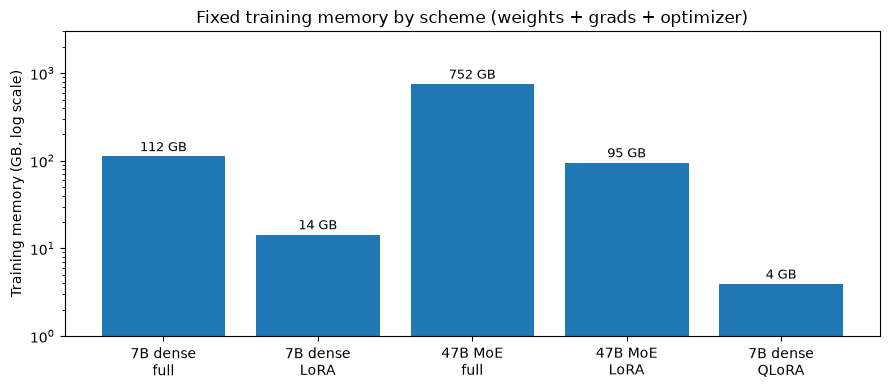

In [4]:
# === 可视化：训练显存估算对比（数值跨度大，用对数轴）===
cases = [
    ("7B dense\nfull", dense_7b, dense_7b, 2),
    ("7B dense\nLoRA", dense_7b, dense_7b * dense_lora_ratio, 2),
    ("47B MoE\nfull", moe_47b, moe_47b, 2),
    ("47B MoE\nLoRA", moe_47b, moe_47b * moe_lora_ratio, 2),
    ("7B dense\nQLoRA", dense_7b, dense_7b * dense_lora_ratio, 0.5),
]
# 口径和上面的 training_memory 相同：冻结部分按 frozen_bytes 存，可训练部分 16 bytes
gbs = [((total - train) * fb + train * 16) / 1e9
       for _, total, train, fb in cases]

plt.figure(figsize=(9, 4))
bars = plt.bar([name for name, *_ in cases], gbs)
for bar, gb in zip(bars, gbs):
    plt.text(bar.get_x() + bar.get_width() / 2, gb * 1.15,
             f"{gb:.0f} GB", ha="center", fontsize=9)
plt.yscale("log")
plt.ylim(1, 3000)
plt.ylabel("Training memory (GB, log scale)")
plt.title("Fixed training memory by scheme (weights + grads + optimizer)")
plt.tight_layout()
plt.show()


## 2. LoRA 的公式与初始化：先手算一遍

LoRA 挂在线性层旁边。原来的计算是 $h = W_0 x$，挂上之后变成：

$$h = W_0 x + \frac{\alpha}{r} BAx$$

各符号的含义：

- $W_0$：预训练权重，形状 $d_{out} \times d_{in}$，冻结不训练
- $A$：形状 $r \times d_{in}$，随机初始化，可训练
- $B$：形状 $d_{out} \times r$，初始化为全 0，可训练
- $r$：秩，通常取 8、16、32；$\Delta W = BA$ 由 $r$ 个外积叠加而成
- $\alpha$：缩放系数，与 $r$ 相除后控制旁路输出强度

数据流向是 $x$ 先经 $A$ 压到 $r$ 维，再经 $B$ 升回 $d_{out}$ 维。训练时梯度只流向 A 和 B，$W_0$ 保持不变。

初始化有两个细节需要说明。

**为什么 B 初始化为全 0？** 训练开始时 $\Delta W = BA = 0$，模型输出和预训练模型完全相同。偏移是训练中逐步学出来的，不会在起点就破坏基座能力。

**为什么 A 不能也是全 0？** 如果 A 和 B 都是 0，两条梯度都会是 0：A 的梯度要经过 B 反传，B 的梯度要经过 A 正传，两边互相卡住，参数永远不动。所以两边不能都是零：随机初始化的 A 提供方向，全零的 B 保证初始输出为零。

In [5]:
# 手算一次 LoRA 前向：d_in=4, d_out=4, r=2, alpha=2
d_in, d_out, r, alpha = 4, 4, 2, 2

W0 = torch.tensor([
    [ 0.5, -0.3,  0.8, -0.2],
    [-0.4,  0.6, -0.1,  0.7],
    [ 0.3, -0.5, -0.6,  0.4],
    [-0.7,  0.2,  0.5, -0.8],
])
A = torch.randn(r, d_in) * 0.02      # 2x4，随机初始化
B = torch.zeros(d_out, r)            # 4x2，全 0 初始化
x = torch.tensor([1.0, 0.5, -0.5, -1.0])

h_base = W0 @ x                      # 原模型的输出

z = A @ x                            # Step 1: 2x4 @ 4 -> 降到 r=2 维
delta = (B @ z) * (alpha / r)        # Step 2: 4x2 @ 2 -> 升回 4 维，再乘缩放
h_lora = h_base + delta

print("输入 x:", x.tolist())
print("原始输出 W0 @ x:", [round(t, 4) for t in h_base.tolist()])
print()
print("Step 1  A @ x（降到 2 维）:", [round(t, 4) for t in z.tolist()])
print("Step 2  B @ z（升回 4 维）:", [round(t, 4) for t in (B @ z).tolist()])
print("缩放 alpha / r =", alpha / r)
print()
print("LoRA 输出:", [round(t, 4) for t in h_lora.tolist()])
print("关键观察：B 全 0 时旁路输出恰好为 0，LoRA 输出与原模型完全相同。")
print("训练做的事，就是让 B 离开全零状态，旁路开始产生修正量。")

输入 x: [1.0, 0.5, -0.5, -1.0]
原始输出 W0 @ x: [0.15, -0.75, -0.05, -0.05]

Step 1  A @ x（降到 2 维）: [0.0011, -0.0336]
Step 2  B @ z（升回 4 维）: [0.0, 0.0, 0.0, 0.0]
缩放 alpha / r = 1.0

LoRA 输出: [0.15, -0.75, -0.05, -0.05]
关键观察：B 全 0 时旁路输出恰好为 0，LoRA 输出与原模型完全相同。
训练做的事，就是让 B 离开全零状态，旁路开始产生修正量。


In [6]:
# 反例验证：A、B 都初始化为全 0 会怎样
A0 = torch.zeros(2, 4, requires_grad=True)
B0 = torch.zeros(4, 2, requires_grad=True)
x_probe = torch.randn(4)

loss = (B0 @ (A0 @ x_probe)).pow(2).sum()
loss.backward()

print("A 的梯度最大值:", A0.grad.abs().max().item())
print("B 的梯度最大值:", B0.grad.abs().max().item())
print()
print("关键观察：两个梯度都恰好是 0，优化器没有任何方向可走。")
print("所以 LoRA 选择「A 随机 + B 全零」：输出从零出发，梯度也活着。")

A 的梯度最大值: 0.0
B 的梯度最大值: 0.0

关键观察：两个梯度都恰好是 0，优化器没有任何方向可走。
所以 LoRA 选择「A 随机 + B 全零」：输出从零出发，梯度也活着。


## 3. 实现 LoraLinear：冻结、旁路、合并

把公式翻译成一个 nn.Module。`LoraLinear` 包装一个现成的 `nn.Linear`，做三件事：

1. 冻结：把内部线性层 weight 和 bias 的 `requires_grad` 关掉
2. 旁路：持有 `lora_A`、`lora_B` 两个 Parameter，forward 输出 $W_0 x + \frac{\alpha}{r}BAx$
3. 合并：提供 `merged_linear()`，把 $W_0 + \frac{\alpha}{r}BA$ 算成一个新矩阵，返回普通 `nn.Linear`

对外接口和 `nn.Linear` 完全一致，所以它可以替换模型里任何一个线性层——这是后面「注入」能几行代码完成的原因。

In [7]:
class LoraLinear(nn.Module):
    """给一个 nn.Linear 挂 LoRA 旁路：y = W0 x + (alpha/r) * B(A(x))

    参数:
        linear: 被包装的原始线性层，权重会被冻结
        r: 秩，旁路的中间维度
        alpha: 缩放系数，实际缩放为 alpha / r
    """

    def __init__(self, linear, r=8, alpha=16):
        super().__init__()
        self.linear = linear
        self.in_features = linear.in_features
        self.out_features = linear.out_features
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r

        # 冻结原始权重：梯度不再流向 W0
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        # A: r x d_in 随机初始化；B: d_out x r 全零初始化
        self.lora_A = nn.Parameter(torch.randn(r, self.in_features) * 0.02)
        self.lora_B = nn.Parameter(torch.zeros(self.out_features, r))

    def forward(self, x):
        # 主路：冻结的 W0 x
        original = self.linear(x)
        # 旁路：降到 r 维再升回来，乘缩放
        bypass = (x @ self.lora_A.T) @ self.lora_B.T * self.scaling
        return original + bypass

    def merged_linear(self):
        """把旁路合并进权重，返回一个普通的 nn.Linear，推理零额外开销"""
        merged = nn.Linear(
            self.in_features, self.out_features,
            bias=self.linear.bias is not None,
        )
        with torch.no_grad():
            delta_w = self.lora_B @ self.lora_A * self.scaling
            merged.weight.copy_(self.linear.weight + delta_w)
            if self.linear.bias is not None:
                merged.bias.copy_(self.linear.bias)
        return merged


print("LoraLinear 定义完成：冻结、旁路、合并三件事各占一个方法或属性。")

LoraLinear 定义完成：冻结、旁路、合并三件事各占一个方法或属性。


In [8]:
# 三项验证：初始等价 / 只有 A、B 可训练 / 合并等价
torch.manual_seed(0)
base = nn.Linear(6, 4, bias=True)
layer = LoraLinear(base, r=2, alpha=4)
x = torch.randn(3, 6)

# 验证 1：刚挂上 LoRA 时，输出与原层完全相同
with torch.no_grad():
    diff = (layer(x) - base(x)).abs().max().item()
print("验证 1：初始输出与原层的最大差异 =", diff)
assert diff == 0.0

# 验证 2：可训练的只有 lora_A 和 lora_B
trainable = [n for n, p in layer.named_parameters() if p.requires_grad]
print("验证 2：可训练参数 =", trainable)
assert trainable == ["lora_A", "lora_B"]

# 验证 3：把 B 改成非零（模拟训练了一阵），合并前后输出一致
with torch.no_grad():
    layer.lora_B.normal_(0, 0.1)
merged = layer.merged_linear()
with torch.no_grad():
    diff = (merged(x) - layer(x)).abs().max().item()
print("验证 3：合并前后输出的最大差异 =", diff)
assert diff < 1e-6
print()
print("关键观察：旁路和合并后的大矩阵在数学上等价，只差浮点舍入误差。")

验证 1：初始输出与原层的最大差异 = 0.0
验证 2：可训练参数 = ['lora_A', 'lora_B']
验证 3：合并前后输出的最大差异 = 1.1920928955078125e-07

关键观察：旁路和合并后的大矩阵在数学上等价，只差浮点舍入误差。


## 4. 准备基座模型：训练一节的管线，配一副完整骨架

训练一节的 `TinyCausalLM` 只有两个矩阵，这是为了聚焦 loss 做的简化。LoRA 要挂在 Attention 和 FFN 的线性层上，这个骨架不够用。这里把骨架升级成完整 decoder：Attention 四个投影矩阵 + FFN 两层，就是 Part 1 MiniGPT 的结构。

训练管线原样沿用训练一节那一套：

- next-token prediction，数据里做 shift（input 去尾、label 去头）
- SFT 只对 assistant 回复算 loss，其余位置 label 设为 -100
- `simple_collate` 拼 batch：input 补 PAD、label 补 -100
- 迷你训练 loop + AdamW

Attention 投影故意拆成四个具名 Linear（`W_Q`/`W_K`/`W_V`/`W_O`），FFN 拆成 `w_up`/`w_down`——这些名字后面要用来决定给谁挂 LoRA。

In [9]:
def sinusoidal_pos(max_len, d_model):
    """固定正弦位置编码，Part 1 用过的同款

    参数:
        max_len: 最大序列长度
        d_model: 隐藏维度

    返回:
        [max_len, d_model] 的位置编码矩阵
    """
    pos = torch.arange(max_len).unsqueeze(1)
    div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe


class CausalSelfAttention(nn.Module):
    """多头因果自注意力，四个投影拆成具名 Linear，方便逐个挂 LoRA

    参数:
        d_model: 隐藏维度
        num_heads: 注意力头数
    """

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, S, D = x.shape
        q = self.W_Q(x).view(B, S, self.num_heads, self.d_head).transpose(1, 2)
        k = self.W_K(x).view(B, S, self.num_heads, self.d_head).transpose(1, 2)
        v = self.W_V(x).view(B, S, self.num_heads, self.d_head).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_head)
        causal = torch.triu(torch.ones(S, S, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(causal, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, S, D)
        return self.W_O(out)


class FFN(nn.Module):
    """两层 FFN：升维 -> GELU -> 降维。MoE 一节里被拆成专家的就是这个结构"""

    def __init__(self, d_model, ffn_dim):
        super().__init__()
        self.w_up = nn.Linear(d_model, ffn_dim)
        self.w_down = nn.Linear(ffn_dim, d_model)

    def forward(self, x):
        return self.w_down(F.gelu(self.w_up(x)))


class DenseBlock(nn.Module):
    """pre-norm Transformer block：Attention 和 FFN 各配一条残差连接"""

    def __init__(self, d_model, num_heads, ffn_dim):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, num_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FFN(d_model, ffn_dim)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class MiniLM(nn.Module):
    """迷你 decoder-only 语言模型，接口与训练一节的 TinyCausalLM 相同

    参数:
        vocab_size: 词表大小
        blocks: Transformer block 列表。放 DenseBlock 是 dense 模型，
                放 MoEBlock（后面定义）就是 MoE 模型
        d_model: 隐藏维度
        max_len: 支持的最大序列长度
    """

    def __init__(self, vocab_size, blocks, d_model, max_len=32):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.register_buffer("pos_encoding", sinusoidal_pos(max_len, d_model))
        self.blocks = nn.ModuleList(blocks)
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids, attention_mask=None, labels=None):
        """输入 token ids 输出 logits；给了 labels 就顺手算 loss

        attention_mask 与训练一节相同，仅为对齐接口保留，不参与计算
        """
        S = input_ids.size(1)
        x = self.token_embedding(input_ids) + self.pos_encoding[:S]
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
                ignore_index=-100,
            )
        return {"loss": loss, "logits": logits}


print("MiniLM 骨架定义完成：Attention 四个投影 + FFN 两层，全部是具名 Linear。")

MiniLM 骨架定义完成：Attention 四个投影 + FFN 两层，全部是具名 Linear。


In [10]:
# 构造 SFT 数据：小词表 + 8 条对话，规则沿用训练一节
PAD_ID, BOS_ID, EOS_ID, ASST_ID = 0, 1, 2, 3

chars = "你好有事请讲是谁我小助手今天气如何晴适合出门谢不客再祝会写代码点几一吗模星期人"
id_of = {"<pad>": PAD_ID, "<bos>": BOS_ID, "<eos>": EOS_ID, "<asst>": ASST_ID}
for ch in chars:
    id_of[ch] = len(id_of)
token_of = {i: t for t, i in id_of.items()}
VOCAB_SIZE = len(id_of)

conversations = [
    ("你好", "你好有事请讲"),
    ("你是谁", "我是小助手"),
    ("今天天气如何", "今天晴适合出门"),
    ("谢谢", "不客气"),
    ("再见", "再见祝好"),
    ("你会写代码", "会写一点代码"),
    ("今天星期几", "今天是星期一"),
    ("你是人吗", "我不是人我是模型"),
]


def encode(text):
    """逐字查词表；查不到的字符直接跳过（教学用小词表）"""
    return [id_of[ch] for ch in text if ch in id_of]


def build_sample(user_text, assistant_text):
    """把一条对话变成训练一节格式的样本：input 去尾、labels 去头

    只有 assistant 回复（含结尾 <eos>）参与 loss，其余位置设为 -100
    """
    user_ids = encode(user_text)
    asst_ids = encode(assistant_text)
    seq = [BOS_ID] + user_ids + [ASST_ID] + asst_ids + [EOS_ID]
    asst_pos = 1 + len(user_ids) + 1              # 第一个 assistant token 的下标
    labels = []
    for i in range(1, len(seq)):                  # labels[i-1] 是看到 seq[:i] 后应预测的 token
        labels.append(seq[i] if i >= asst_pos else -100)
    return {"input_ids": seq[:-1], "labels": labels}


print("词表大小:", VOCAB_SIZE, " 对话条数:", len(conversations))

词表大小: 43  对话条数: 8


In [11]:
# 打印一条样本的监督关系：哪些位置算 loss、哪些不算
sample = build_sample("你会写代码", "会写一点代码")
tokens = [token_of[t] for t in sample["input_ids"]]

for i, (tok, lab) in enumerate(zip(tokens, sample["labels"])):
    if lab == -100:
        print(f"位置 {i}: 看到 {tokens[: i + 1]} -> 不算 loss")
    else:
        print(f"位置 {i}: 看到 {tokens[: i + 1]} -> 预测 {token_of[lab]}")

print()
print("关键观察：只有 assistant 回复和 <eos> 参与 loss，user 和模板标记全部忽略。")

位置 0: 看到 ['<bos>'] -> 不算 loss
位置 1: 看到 ['<bos>', '你'] -> 不算 loss
位置 2: 看到 ['<bos>', '你', '会'] -> 不算 loss
位置 3: 看到 ['<bos>', '你', '会', '写'] -> 不算 loss
位置 4: 看到 ['<bos>', '你', '会', '写', '代'] -> 不算 loss
位置 5: 看到 ['<bos>', '你', '会', '写', '代', '码'] -> 不算 loss
位置 6: 看到 ['<bos>', '你', '会', '写', '代', '码', '<asst>'] -> 预测 会
位置 7: 看到 ['<bos>', '你', '会', '写', '代', '码', '<asst>', '会'] -> 预测 写
位置 8: 看到 ['<bos>', '你', '会', '写', '代', '码', '<asst>', '会', '写'] -> 预测 一
位置 9: 看到 ['<bos>', '你', '会', '写', '代', '码', '<asst>', '会', '写', '一'] -> 预测 点
位置 10: 看到 ['<bos>', '你', '会', '写', '代', '码', '<asst>', '会', '写', '一', '点'] -> 预测 代
位置 11: 看到 ['<bos>', '你', '会', '写', '代', '码', '<asst>', '会', '写', '一', '点', '代'] -> 预测 码
位置 12: 看到 ['<bos>', '你', '会', '写', '代', '码', '<asst>', '会', '写', '一', '点', '代', '码'] -> 预测 <eos>

关键观察：只有 assistant 回复和 <eos> 参与 loss，user 和模板标记全部忽略。


In [12]:
# 训练一节的 simple_collate 原样搬来：pad 输入、-100 补 labels
def simple_collate(features, pad_id=PAD_ID, ignore_index=-100):
    """把多条样本补齐成一个 batch

    参数:
        features: 每条样本包含 input_ids 和 labels
        pad_id: input_ids 的填充 id
        ignore_index: labels 的忽略标记

    返回:
        包含 input_ids、attention_mask、labels 的 batch 字典
    """
    max_len = max(len(f["input_ids"]) for f in features)
    batch_ids, batch_mask, batch_labels = [], [], []
    for f in features:
        pad = max_len - len(f["input_ids"])
        batch_ids.append(f["input_ids"] + [pad_id] * pad)
        batch_mask.append([1] * len(f["input_ids"]) + [0] * pad)
        batch_labels.append(f["labels"] + [ignore_index] * pad)
    return {
        "input_ids": torch.tensor(batch_ids),
        "attention_mask": torch.tensor(batch_mask),
        "labels": torch.tensor(batch_labels),
    }


class SFTDataset(Dataset):
    """把对话列表包成 Dataset，每条返回一个样本字典"""

    def __init__(self, conversations):
        self.samples = [build_sample(u, a) for u, a in conversations]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]


sft_dataset = SFTDataset(conversations)
sft_loader = DataLoader(sft_dataset, batch_size=4, shuffle=False, collate_fn=simple_collate)
first_batch = next(iter(sft_loader))

for name, value in first_batch.items():
    print(f"{name}: shape = {tuple(value.shape)}")
print()
print("关键观察：从这里开始，batch 的形状和训练一节完全一致。")

input_ids: shape = (4, 15)
attention_mask: shape = (4, 15)
labels: shape = (4, 15)

关键观察：从这里开始，batch 的形状和训练一节完全一致。


### 先把基座预训练一下

这里有个容易忽略的前提：LoRA 假设基座是预训练好的。如果拿随机初始化的基座做 SFT，冻结的 embedding 和 lm_head 还是随机矩阵，对 LoRA 不公平，也和真实场景不符。

所以先用一批普通句子把基座预训练到「会一点这门语言」——做法和预训练一节相同：整句算 next-token loss，不 mask 任何位置。语料故意和 SFT 对话不同，模拟「基座的通用语料 vs 我们的领域数据」。

In [13]:
def train_one_model(model, dataloader, epochs, lr):
    """训练一节的迷你训练 loop 原样搬来：只把可训练参数交给 optimizer

    参数:
        model: 模型
        dataloader: 训练数据
        epochs: 训练轮数
        lr: 学习率

    返回:
        每个 epoch 的平均 loss 列表
    """
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=lr)
    history = []
    model.train()
    for epoch in range(epochs):
        total, steps = 0.0, 0
        for batch in dataloader:
            loss = model(**batch)["loss"]
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += loss.item()
            steps += 1
        history.append(total / steps)
    return history


# 预训练语料：普通句子，与 SFT 对话不同（模拟基座的通用语料）
pretrain_sentences = [
    "今天天气晴适合出门",
    "今天星期一出门写代码",
    "我是谁我是小助手",
    "你好请讲你是谁",
    "今天写代码写一点代码",
    "再见祝你今天出门",
    "天气如何今天出门吗",
    "我是模型我会写代码",
]


def pretrain_sample(text):
    """预训练样本：整句算 loss，不 mask 任何位置（与预训练一节相同）"""
    ids = [BOS_ID] + encode(text) + [EOS_ID]
    return {"input_ids": ids[:-1], "labels": ids[1:]}


class PretrainDataset(Dataset):
    """把预训练句子包成 Dataset"""

    def __init__(self, sentences):
        self.samples = [pretrain_sample(s) for s in sentences]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        return self.samples[index]


pretrain_loader = DataLoader(
    PretrainDataset(pretrain_sentences),
    batch_size=4,
    shuffle=False,
    collate_fn=simple_collate,
)

# dense 基座：构建 + 预训练
torch.manual_seed(42)
dense_base = MiniLM(
    VOCAB_SIZE,
    [DenseBlock(64, 4, ffn_dim=256) for _ in range(2)],
    d_model=64,
)
pretrain_history = train_one_model(dense_base, pretrain_loader, epochs=80, lr=1e-3)
print(f"dense 基座预训练完成，loss 从 {pretrain_history[0]:.4f} 降到 {pretrain_history[-1]:.4f}")
print("关键观察：基座学会了这些字的常见搭配，但没见过 SFT 对话，微调要学的内容还在。")

dense 基座预训练完成，loss 从 3.8775 降到 0.2572
关键观察：基座学会了这些字的常见搭配，但没见过 SFT 对话，微调要学的内容还在。


## 5. 注入 LoRA：换哪些层、怎么换、怎么冻结

LoRA 最主要的自由度是挂哪些层。常见配置有三种：

| 配置 | 挂在哪 | 来源 |
|:--|:--|:--|
| 保守 | 只有 `W_Q`、`W_V` | LoRA 原论文（2021） |
| 常用 | Attention 四个投影 + FFN 两层（all-linear） | QLoRA 论文及后续实践 |
| 谨慎 | 再加 embedding / lm_head | 一般不挂：与输出语义强相关，参数也大 |

原则是：微调要改的是「中间表示的变换方式」，所以挂在 Attention 和 FFN 的投影矩阵上；词嵌入和输出投影动起来风险大、收益小。

注入本身只是模块替换：遍历模型，遇到名字在目标名单里的 `nn.Linear`，就把它包进 `LoraLinear`。注入之后还有一步容易漏掉：把没挂 LoRA 的其他参数（LayerNorm、词嵌入、没被点名的投影）全部冻结。「只训 LoRA」指的是整个模型只有 A、B 可训练。

In [14]:
def inject_lora(model, target_names, r=8, alpha=16):
    """把模型里名字匹配的 nn.Linear 换成 LoraLinear，其余参数全部冻结

    参数:
        model: 待注入的模型（原地修改）
        target_names: 要挂 LoRA 的子模块名集合，如 {"W_Q", "W_V"}
        r: LoRA 秩
        alpha: 缩放系数

    返回:
        注入后的模型
    """
    for name, module in model.named_modules():
        for child_name, child in module.named_children():
            if child_name in target_names and isinstance(child, nn.Linear):
                setattr(module, child_name, LoraLinear(child, r=r, alpha=alpha))
    # 名单之外的参数一律冻结：这才是「只训 LoRA」
    for p in model.parameters():
        p.requires_grad = False
    for n, p in model.named_parameters():
        if "lora_" in n:
            p.requires_grad = True
    return model


def param_audit(model, name=""):
    """统计并打印总参数量、可训练参数量和占比"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{name}] 总参数 {total:,}  可训练 {trainable:,}  ({trainable / total:.2%})")
    return total, trainable


# 以原论文的 q,v 配置演示注入
param_audit(dense_base, "dense 基座（已预训练）")
dense_lora = inject_lora(
    copy.deepcopy(dense_base), target_names={"W_Q", "W_V"}, r=8, alpha=16
)
param_audit(dense_lora, "挂上 LoRA 后")

print()
lora_names = [n for n, _ in dense_lora.named_parameters() if "lora_" in n]
print("LoRA 张量:", lora_names)
print("关键观察：可训练的只剩每层 W_Q、W_V 的 A、B。")
print("迷你模型上这个比例约 4%；真实 7B 模型维度大得多，同配置只有 0.1% 量级。")

[dense 基座（已预训练）] 总参数 105,088  可训练 105,088  (100.00%)
[挂上 LoRA 后] 总参数 109,184  可训练 4,096  (3.75%)

LoRA 张量: ['blocks.0.attn.W_Q.lora_A', 'blocks.0.attn.W_Q.lora_B', 'blocks.0.attn.W_V.lora_A', 'blocks.0.attn.W_V.lora_B', 'blocks.1.attn.W_Q.lora_A', 'blocks.1.attn.W_Q.lora_B', 'blocks.1.attn.W_V.lora_A', 'blocks.1.attn.W_V.lora_B']
关键观察：可训练的只剩每层 W_Q、W_V 的 A、B。
迷你模型上这个比例约 4%；真实 7B 模型维度大得多，同配置只有 0.1% 量级。


## 6. dense 基座实验：冻结 vs 两种 LoRA vs 全量微调

四个模型用同一份预训练初始化、同一批数据、同一个训练 loop，只改「哪些参数可训练」：

- **全量微调**：所有参数可训练
- **LoRA（all-linear）**：Attention 四个投影 + FFN 两层都挂，上表的「常用」配置
- **LoRA（q,v）**：只挂 `W_Q`、`W_V`，原论文的保守配置
- **冻结基座**：什么都不训练，loss 停在预训练水平，作为参照线

LoRA 的容量比全量微调小，最终 loss 不一定同样低。这里观察两点：它能否用很少的参数把 loss 降到远低于冻结基座；all-linear 和 q,v 两种配置差多少。

In [15]:
EPOCHS = 150
ALL_LINEAR = {"W_Q", "W_K", "W_V", "W_O", "w_up", "w_down"}

# 三个模型：同一份预训练初始化，只差「谁可训练」
full_model = copy.deepcopy(dense_base)
lora_model = inject_lora(copy.deepcopy(dense_base), ALL_LINEAR, r=8, alpha=16)
lora_qv_model = dense_lora           # 上一节挂好 q,v LoRA 的模型

with torch.no_grad():
    frozen_loss = dense_base(**first_batch)["loss"].item()
print(f"冻结基座在 SFT 数据上的 loss = {frozen_loss:.4f}（预训练过，但没见过这些对话）")
print()

print("训练全量微调 ...")
history_full = train_one_model(full_model, sft_loader, EPOCHS, lr=1e-3)
print("训练 LoRA（all-linear）...")
history_lora = train_one_model(lora_model, sft_loader, EPOCHS, lr=3e-3)
print("训练 LoRA（q,v）...")
history_lora_qv = train_one_model(lora_qv_model, sft_loader, EPOCHS, lr=3e-3)

n_full = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
n_lora = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
n_qv = sum(p.numel() for p in lora_qv_model.parameters() if p.requires_grad)
print(f"全量微调        最终 loss: {history_full[-1]:.4f}（可训练 {n_full:,}）")
print(f"LoRA all-linear 最终 loss: {history_lora[-1]:.4f}（可训练 {n_lora:,}）")
print(f"LoRA q,v        最终 loss: {history_lora_qv[-1]:.4f}（可训练 {n_qv:,}）")

冻结基座在 SFT 数据上的 loss = 2.1709（预训练过，但没见过这些对话）

训练全量微调 ...


训练 LoRA（all-linear）...


训练 LoRA（q,v）...


全量微调        最终 loss: 0.0048（可训练 105,088）
LoRA all-linear 最终 loss: 0.0744（可训练 18,432）
LoRA q,v        最终 loss: 0.2017（可训练 4,096）


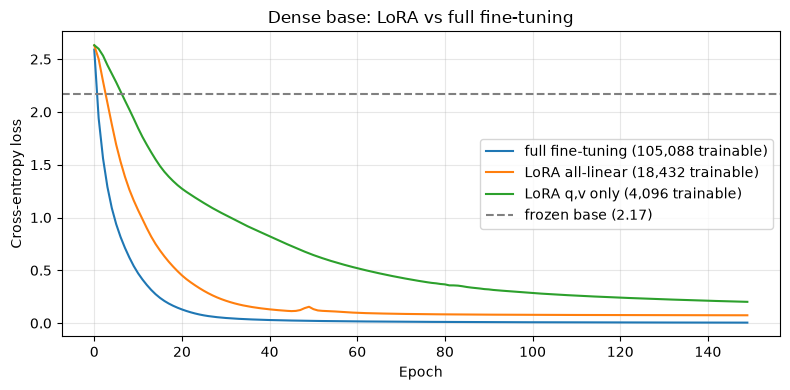

In [16]:
# 画四条 loss 曲线：全量微调、两种 LoRA、冻结基座
plt.figure(figsize=(8, 4))
plt.plot(history_full, label=f"full fine-tuning ({n_full:,} trainable)")
plt.plot(history_lora, label=f"LoRA all-linear ({n_lora:,} trainable)")
plt.plot(history_lora_qv, label=f"LoRA q,v only ({n_qv:,} trainable)")
plt.axhline(frozen_loss, color="gray", linestyle="--", label=f"frozen base ({frozen_loss:.2f})")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Dense base: LoRA vs full fine-tuning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
def merge_lora(model):
    """把模型里所有 LoraLinear 替换成合并后的普通 nn.Linear（原地修改）

    参数:
        model: 挂着 LoraLinear 的模型

    返回:
        合并后的模型
    """
    for name, module in list(model.named_modules()):
        for child_name, child in list(module.named_children()):
            if isinstance(child, LoraLinear):
                setattr(module, child_name, child.merged_linear())
    return model


# 验证 1：LoRA 训练完，基座权重逐位不变
base_params = dict(dense_base.named_parameters())
changed = []
for name, p in lora_model.named_parameters():
    if "lora_" in name:
        continue
    base_name = name.replace(".linear.", ".")    # W_Q.linear.weight -> W_Q.weight
    if not torch.equal(base_params[base_name], p.detach()):
        changed.append(name)
assert changed == [], f"这些基座参数不应该变: {changed}"
print("验证 1 通过：除 lora_A / lora_B 外，全部参数与预训练基座逐位相同。")

# 验证 2：合并前后，模型输出一致
with torch.no_grad():
    logits_bypass = lora_model(**first_batch)["logits"]
merged_model = merge_lora(copy.deepcopy(lora_model))
with torch.no_grad():
    logits_merged = merged_model(**first_batch)["logits"]
max_diff = (logits_bypass - logits_merged).abs().max().item()
print(f"验证 2：合并前后 logits 最大差异 = {max_diff:.2e}")
assert max_diff < 1e-4
print("合并后的模型就是普通 MiniLM，推理没有任何旁路开销。")

验证 1 通过：除 lora_A / lora_B 外，全部参数与预训练基座逐位相同。
验证 2：合并前后 logits 最大差异 = 5.22e-06
合并后的模型就是普通 MiniLM，推理没有任何旁路开销。


## 7. 换基座：把 MoE 一节的 MoE 层放进 MiniLM

MoE 模型的 LoRA 和 dense 有两点不同：FFN 换成了规模大得多的专家群，参数占比进一步上升；多出一个 router。先把 MoE 一节的 `MoELayer` 搬进来。

那一节的教学版用三层 for 循环逐 token 路由，语义最直白但太慢。这里改成按专家分组：每个专家只处理路由到自己的 token。数学与循环版完全一致——gate 打分、top-k、对选中的 logits 做 softmax、加权求和。

有一处小改动：那一节的专家用 `nn.Sequential` 写，子模块名字是数字下标；这里拆成具名的 `Expert` 类（`w_up`/`w_down`），理由和 Attention 拆具名投影相同——注入 LoRA 时要靠名字匹配。

In [18]:
class Expert(nn.Module):
    """单个专家：一个两层 FFN

    和 dense 版 FFN 结构相同，矩阵同样叫 w_up / w_down——
    挂 LoRA 时和 Attention 的投影用同一套名单即可
    """

    def __init__(self, d_model, expert_dim):
        super().__init__()
        self.w_up = nn.Linear(d_model, expert_dim)
        self.w_down = nn.Linear(expert_dim, d_model)

    def forward(self, x):
        return self.w_down(F.gelu(self.w_up(x)))


class MoELayer(nn.Module):
    """MoE 一节的 MoE 层：gate 打分 -> top-k -> 加权求和

    参数:
        d_model: 隐藏维度
        num_experts: 专家数量
        top_k: 每个 token 激活的专家数
        expert_dim: 单个专家的中间维度
    """

    def __init__(self, d_model, num_experts=8, top_k=2, expert_dim=256):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.gate = nn.Linear(d_model, num_experts, bias=False)
        self.experts = nn.ModuleList([
            Expert(d_model, expert_dim) for _ in range(num_experts)
        ])

    def forward(self, x):
        B, S, D = x.shape
        gate_logits = self.gate(x)                          # [B, S, N]
        top_logits, top_idx = torch.topk(gate_logits, self.top_k, dim=-1)
        top_weights = F.softmax(top_logits, dim=-1)         # [B, S, k]

        flat_x = x.reshape(-1, D)
        flat_idx = top_idx.reshape(-1, self.top_k)
        flat_w = top_weights.reshape(-1, self.top_k)
        out = x.new_zeros(B * S, D)

        # 逐专家处理：只把路由到自己的 token 送进来
        for e in range(self.num_experts):
            hit = flat_w * (flat_idx == e)      # 命中槽位的权重，未命中为 0
            w_e = hit.sum(dim=-1)               # 每个 token 分给专家 e 的权重
            rows = w_e.nonzero().squeeze(-1)
            if rows.numel() == 0:
                continue
            expert_out = self.experts[e](flat_x[rows])
            out = out.index_add(0, rows, w_e[rows].unsqueeze(-1) * expert_out)

        return out.reshape(B, S, D)


class MoEBlock(nn.Module):
    """DenseBlock 的 MoE 版：Attention 原样保留，FFN 换成 MoELayer"""

    def __init__(self, d_model, num_heads, num_experts=8, top_k=2, expert_dim=256):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, num_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.moe = MoELayer(d_model, num_experts, top_k, expert_dim)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.moe(self.ln2(x))
        return x


torch.manual_seed(42)
moe_base = MiniLM(
    VOCAB_SIZE,
    [MoEBlock(64, 4, num_experts=8, top_k=2, expert_dim=256) for _ in range(2)],
    d_model=64,
)
print("MoE 基座构建完成：2 层，每层 8 个专家，top-2 路由。")

# 和 dense 基座一样：先预训练，再当微调的起点
pretrain_moe_history = train_one_model(moe_base, pretrain_loader, epochs=80, lr=1e-3)
print(f"MoE 基座预训练完成，loss 从 {pretrain_moe_history[0]:.4f} 降到 {pretrain_moe_history[-1]:.4f}")

MoE 基座构建完成：2 层，每层 8 个专家，top-2 路由。


MoE 基座预训练完成，loss 从 3.8415 降到 0.2538


In [19]:
# 参数分布审计：MoE 模型的参数大头在哪里
def param_breakdown(model):
    """按部位统计参数量：attention / gate / experts / 其它"""
    groups = {"attention": 0, "router(gate)": 0, "experts(FFN)": 0, "embedding+lm_head": 0}
    for name, p in model.named_parameters():
        if ".attn." in name:
            groups["attention"] += p.numel()
        elif ".moe.gate." in name:
            groups["router(gate)"] += p.numel()
        elif ".moe.experts." in name:
            groups["experts(FFN)"] += p.numel()
        else:
            groups["embedding+lm_head"] += p.numel()
    total = sum(groups.values())
    for k, v in groups.items():
        print(f"{k:22s} {v:>10,}  ({v / total:.1%})")
    print(f"{'合计':22s} {total:>10,}")
    return groups


param_breakdown(moe_base)
print()
print("关键观察：专家参数约占九成，Attention 约 6%。")
print("全量微调时优化器状态按同样的比例膨胀——这决定了 MoE 上挂 LoRA 的优先位置。")

attention                  32,768  (5.8%)
router(gate)                1,024  (0.2%)
experts(FFN)              529,408  (93.0%)
embedding+lm_head           6,144  (1.1%)
合计                        569,344

关键观察：专家参数约占九成，Attention 约 6%。
全量微调时优化器状态按同样的比例膨胀——这决定了 MoE 上挂 LoRA 的优先位置。


attention                  32,768  (5.8%)
router(gate)                1,024  (0.2%)
experts(FFN)              529,408  (93.0%)
embedding+lm_head           6,144  (1.1%)
合计                        569,344


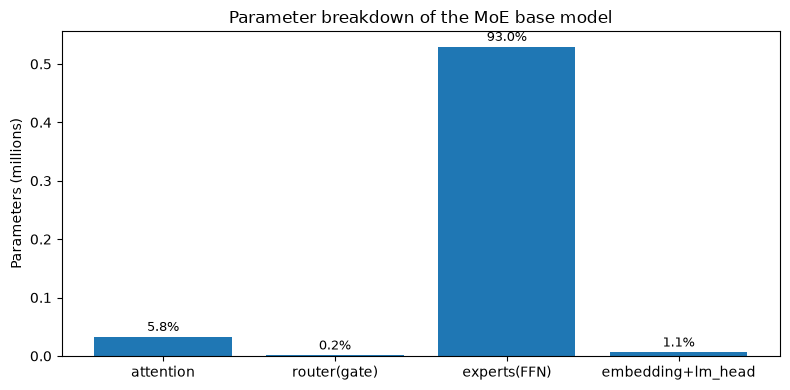

In [20]:
# === 可视化：MoE 模型的参数大头在哪里 ===
groups = param_breakdown(moe_base)

plt.figure(figsize=(8, 4))
bars = plt.bar(groups.keys(), [v / 1e6 for v in groups.values()])
# 柱顶标注占比，和上面打印的数字对上
total = sum(groups.values())
for bar, v in zip(bars, groups.values()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01, f"{v / total:.1%}",
             ha="center", fontsize=9)
plt.ylabel("Parameters (millions)")
plt.title("Parameter breakdown of the MoE base model")
plt.tight_layout()
plt.show()


## 8. MoE 的 LoRA：attention、专家、router 各挂不挂

dense 模型只需要决定挂哪些层，MoE 模型还多出一个 router 的问题。把可挂的位置列出来（占比来自上面迷你模型的统计）：

| 位置 | 参数占比 | 挂 LoRA 的理由 | 不挂的理由 |
|:--|:--|:--|:--|
| Attention 的 `W_Q`/`W_V` 等 | 小（约 6%） | 微调最常见的受益层 | 只动它，专家里的知识改不到 |
| 每个 expert 的 `w_up`/`w_down` | 大（约九成） | 领域知识主要存在 FFN 里，改它最对症 | 专家多，adapter 数量乘 N |
| router 的 `gate` | 极小（0.2%） | — | 动它会改变 token 的分配规则 |

实践里常见的两种组合：只挂 Attention（改动最保守）；Attention 和专家都挂（改动能力最强，Mixtral、DeepSeek 系列的 LoRA 微调通常这样做）。router 一律不挂——它只有几百个参数，挂上去收益接近零，风险却不小：MoE 一节讲过，路由一旦向少数专家倾斜，整个模型的负载都会失衡。

还有一个 dense 模型没有的现象：给专家挂 LoRA 时，8 个专家要各配一对 A、B，adapter 数量是 dense 的 8 倍。而梯度怎么流，取决于路由——每个 token 只经过 top-2 个专家，每个 step 只有被路由到的专家的 A、B 收到梯度。如果某个专家长期闲置，它的 LoRA 也长期收不到梯度，等于没训。

In [21]:
# 给 MoE 基座挂 LoRA：Attention + 全部专家，gate 不动
moe_lora = inject_lora(
    copy.deepcopy(moe_base),
    target_names={"W_Q", "W_V", "w_up", "w_down"},
    r=8,
    alpha=16,
)
param_audit(moe_base, "MoE 基座（已预训练）")
param_audit(moe_lora, "MoE + LoRA(attn+experts)")

n_adapters = len([n for n, _ in moe_lora.named_parameters() if "lora_" in n])
print()
print(f"LoRA 张量共 {n_adapters} 个：每层 W_Q、W_V 两个 + 8 个专家 x 2 个矩阵，")
print("两层共 36 对 A、B。其中专家占 32 对——adapter 开销主要花在专家上。")
print("关键观察：gate 不在名单里，它的权重在训练中保持冻结。")

[MoE 基座（已预训练）] 总参数 569,344  可训练 569,344  (100.00%)
[MoE + LoRA(attn+experts)] 总参数 655,360  可训练 86,016  (13.12%)

LoRA 张量共 72 个：每层 W_Q、W_V 两个 + 8 个专家 x 2 个矩阵，
两层共 36 对 A、B。其中专家占 32 对——adapter 开销主要花在专家上。
关键观察：gate 不在名单里，它的权重在训练中保持冻结。


In [22]:
# MoE 实验：LoRA vs 全量微调，同一初始化、同一数据
EPOCHS_MOE = 120

moe_full = copy.deepcopy(moe_base)

with torch.no_grad():
    frozen_moe_loss = moe_base(**first_batch)["loss"].item()
print(f"冻结 MoE 基座在 SFT 数据上的 loss = {frozen_moe_loss:.4f}")
print()

print("训练 MoE 全量微调 ...")
history_moe_full = train_one_model(moe_full, sft_loader, EPOCHS_MOE, lr=1e-3)
print("训练 MoE LoRA ...")
history_moe_lora = train_one_model(moe_lora, sft_loader, EPOCHS_MOE, lr=3e-3)

n_moe_full = sum(p.numel() for p in moe_full.parameters() if p.requires_grad)
n_moe_lora = sum(p.numel() for p in moe_lora.parameters() if p.requires_grad)
print(f"MoE 全量微调最终 loss: {history_moe_full[-1]:.4f}（可训练 {n_moe_full:,}）")
print(f"MoE LoRA     最终 loss: {history_moe_lora[-1]:.4f}（可训练 {n_moe_lora:,}）")

冻结 MoE 基座在 SFT 数据上的 loss = 2.4355

训练 MoE 全量微调 ...


训练 MoE LoRA ...


MoE 全量微调最终 loss: 0.0060（可训练 569,344）
MoE LoRA     最终 loss: 0.0758（可训练 86,016）


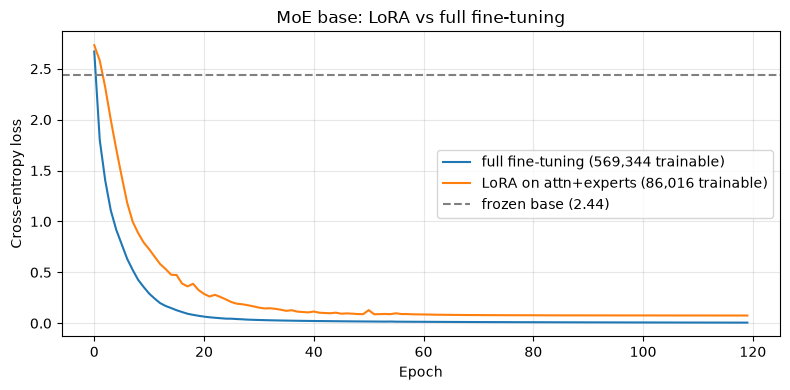

In [23]:
# MoE 的 loss 曲线
plt.figure(figsize=(8, 4))
plt.plot(history_moe_full, label=f"full fine-tuning ({n_moe_full:,} trainable)")
plt.plot(history_moe_lora, label=f"LoRA on attn+experts ({n_moe_lora:,} trainable)")
plt.axhline(frozen_moe_loss, color="gray", linestyle="--", label=f"frozen base ({frozen_moe_loss:.2f})")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("MoE base: LoRA vs full fine-tuning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# 路由稳定性拆成两层看：gate 的权重，和实际的 top-k 选择
def probe_routing(model, batch):
    """前向到第一个 MoE 层，返回 gate 的 top-k 专家编号（只观察，不训练）

    参数:
        model: MoE 模型
        batch: 一个 batch 字典

    返回:
        [B, S, top_k] 的专家编号张量
    """
    with torch.no_grad():
        S = batch["input_ids"].size(1)
        x = model.token_embedding(batch["input_ids"]) + model.pos_encoding[:S]
        block = model.blocks[0]
        x = x + block.attn(block.ln1(x))
        gate_logits = block.moe.gate(block.ln2(x))
        _, top_idx = torch.topk(gate_logits, block.moe.top_k, dim=-1)
    return top_idx


# 第一层：gate 的权重。LoRA 没挂 gate，训练后应该逐位不变
gate_base = moe_base.blocks[0].moe.gate.weight
gate_lora = moe_lora.blocks[0].moe.gate.weight
assert torch.equal(gate_base, gate_lora.detach()), "gate 被冻结，权重不应该变"
print("验证通过：LoRA 训练后，gate 权重逐位不变——打分规则没被训练改动。")

# 第二层：实际路由。它还取决于上游 Attention 的输出，
# 而 Attention 挂了 LoRA、表示变了，所以路由可能轻微移动
routing_base = probe_routing(moe_base, first_batch)
routing_after_lora = probe_routing(moe_lora, first_batch)
routing_after_full = probe_routing(moe_full, first_batch)

gate_drift_full = (gate_base - moe_full.blocks[0].moe.gate.weight).norm().item()
keep_lora = (routing_base == routing_after_lora).float().mean().item()
keep_full = (routing_base == routing_after_full).float().mean().item()
print(f"全量微调改变了 gate 权重本身（变化范数 {gate_drift_full:.3f}，LoRA 是 0）")
print(f"LoRA 训练后，路由与训练前相同的位置比例:   {keep_lora:.1%}")
print(f"全量微调后，路由与训练前相同的位置比例:   {keep_full:.1%}")
print()
usage = torch.bincount(routing_after_lora.flatten(), minlength=8).float()
usage = usage / usage.sum()
print("LoRA 训练后专家使用分布:", [f"{u:.0%}" for u in usage.tolist()])
print()
print("关键观察：LoRA 挂不挂 gate 的区别在打分规则：gate 权重逐位不变，梯度改不了它。")
print("路由仍可能轻微移动：上游 Attention 的适配器改变了表示。所以 MoE + LoRA")
print("虽然不必担心 router 被梯度改写，专家使用率仍然要像 MoE 一节那样持续监控。")

验证通过：LoRA 训练后，gate 权重逐位不变——打分规则没被训练改动。
全量微调改变了 gate 权重本身（变化范数 0.236，LoRA 是 0）
LoRA 训练后，路由与训练前相同的位置比例:   83.3%
全量微调后，路由与训练前相同的位置比例:   65.8%

LoRA 训练后专家使用分布: ['28%', '27%', '12%', '9%', '8%', '10%', '5%', '2%']

关键观察：LoRA 挂不挂 gate 的区别在打分规则：gate 权重逐位不变，梯度改不了它。
路由仍可能轻微移动：上游 Attention 的适配器改变了表示。所以 MoE + LoRA
虽然不必担心 router 被梯度改写，专家使用率仍然要像 MoE 一节那样持续监控。


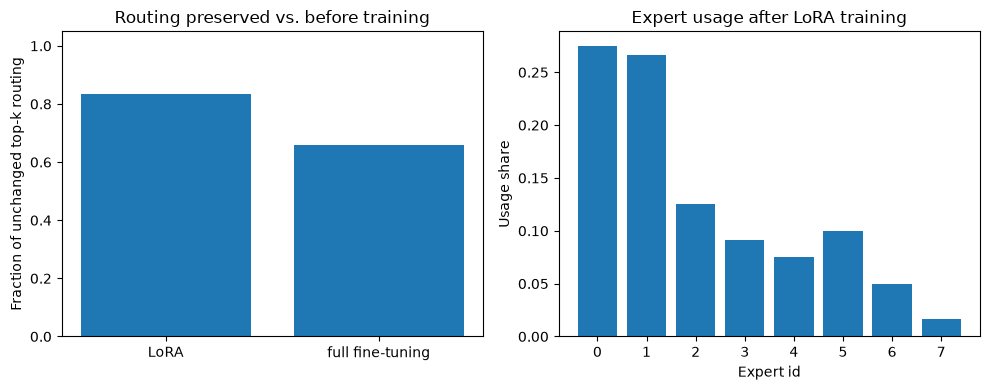

In [25]:
# === 可视化：LoRA 与全量微调的路由稳定性对比 ===
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 左图：训练后路由与训练前相同的位置比例
axes[0].bar(["LoRA", "full fine-tuning"], [keep_lora, keep_full])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Fraction of unchanged top-k routing")
axes[0].set_title("Routing preserved vs. before training")

# 右图：LoRA 训练后 8 个专家的使用率，看有没有明显倾斜
axes[1].bar(range(8), usage.tolist())
axes[1].set_xlabel("Expert id")
axes[1].set_ylabel("Usage share")
axes[1].set_title("Expert usage after LoRA training")

plt.tight_layout()
plt.show()


## 9. 训练之后：合并、只存适配器、多任务切换

训练完成后，LoRA 的权重有三种用法。

**合并部署**。dense 模型的合并前面已经验证过。MoE 模型的合并没有新东西：每个专家的 `w_up`、`w_down` 都是普通线性层，各自做一次 $W_0 + \frac{\alpha}{r}BA$，gate 原样保留。

**只存适配器**。checkpoint 只需要保存 A、B 这些小张量，基座权重不用重复保存。同一个基座，客服 LoRA、代码 LoRA、写作 LoRA 各存一份，每个只有几 MB。

**运行时切换**。不合并的话，推理服务可以让一份基座常驻显存，按请求换不同的 adapter，显存占用比每个任务各部署一个完整模型小得多。vLLM 这类推理框架已经支持同时挂多个 LoRA adapter。

In [26]:
# 合并 MoE 模型，并看看「只存适配器」有多小
with torch.no_grad():
    logits_bypass = moe_lora(**first_batch)["logits"]
moe_merged = merge_lora(copy.deepcopy(moe_lora))
with torch.no_grad():
    logits_merged = moe_merged(**first_batch)["logits"]
diff = (logits_bypass - logits_merged).abs().max().item()
print(f"MoE 合并前后 logits 最大差异 = {diff:.2e}")
assert diff < 1e-4
print("合并后的 MoE 模型结构与原基座完全相同，可以直接部署。")
print()

adapter_sd = {k: v for k, v in moe_lora.state_dict().items() if "lora_" in k}
n_adapter = sum(v.numel() for v in adapter_sd.values())
n_total = sum(p.numel() for p in moe_lora.parameters())
print(f"适配器张量个数: {len(adapter_sd)}")
print(f"适配器参数量:   {n_adapter:,}  占全模型 {n_adapter / n_total:.2%}")
print()
print(f"关键观察：适配器只占 {n_adapter / n_total:.0%} 的参数（迷你模型矩阵小，")
print("比例偏高；真实大模型同配置是 0.1% 量级），一个基座可以服务多个任务。")

MoE 合并前后 logits 最大差异 = 1.91e-06
合并后的 MoE 模型结构与原基座完全相同，可以直接部署。

适配器张量个数: 72
适配器参数量:   86,016  占全模型 13.12%

关键观察：适配器只占 13% 的参数（迷你模型矩阵小，
比例偏高；真实大模型同配置是 0.1% 量级），一个基座可以服务多个任务。


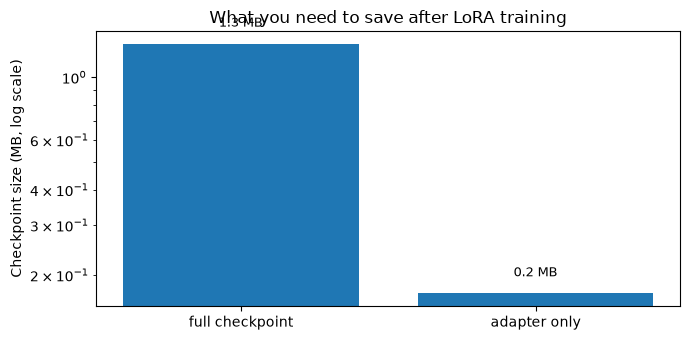

In [27]:
# === 可视化：完整 checkpoint vs 只存适配器 ===
# 都按 FP16（每参数 2 字节）折算成 MB
sizes_mb = [(n_total * 2) / 1e6, (n_adapter * 2) / 1e6]

plt.figure(figsize=(7, 3.5))
bars = plt.bar(["full checkpoint", "adapter only"], sizes_mb)
for bar, mb in zip(bars, sizes_mb):
    plt.text(bar.get_x() + bar.get_width() / 2, mb * 1.15,
             f"{mb:.1f} MB", ha="center", fontsize=9)
plt.yscale("log")
plt.ylabel("Checkpoint size (MB, log scale)")
plt.title("What you need to save after LoRA training")
plt.tight_layout()
plt.show()


## 10. QLoRA 与实践参数速查

LoRA 把可训练参数压小了，但基座权重还要以 FP16 待在显存里，7B 也要 14 GB。QLoRA 把这一半也省了：基座用 4-bit 的 NF4 格式存储（每参数 0.5 byte），前向时反量化回 FP16 参与计算，梯度照旧只流向 LoRA 参数。

冻结和量化之所以能叠加，是因为 LoRA 本来就不更新基座：量化只影响前向的数值精度，不影响「哪些参数接收梯度」。QLoRA 主要由三个技术组成：

| 技术 | 作用 |
|:--|:--|
| NF4（4-bit NormalFloat） | 按权重的正态分布设计 16 个量化级别，信息损失小 |
| Double Quantization | 把量化常量本身再量化一次，每参数再省约 0.4 bit |
| Paged Optimizer | 优化器状态用统一内存分页，抹平显存峰值 |

NF4 的量化级别怎么设计，放在量化一节展开。

In [28]:
# 三种方案的显存对比（7B 基座，all-linear r=16，约 0.4% 参数可训练）
P = 7e9
adapter = P * 0.004

rows = [
    ("full fine-tuning", P * 16),
    ("LoRA (FP16 base)", (P - adapter) * 2 + adapter * 16),
    ("QLoRA (NF4 base)", (P - adapter) * 0.5 + adapter * 16),
]
print(f"{'方案':<20}{'固定显存'}")
for name, b in rows:
    print(f"{name:<20}{b / 1e9:6.1f} GB")
print()
print("关键观察：QLoRA 的节省来自两层叠加——")
print("LoRA 砍掉梯度和优化器状态，量化砍掉冻结权重的存储精度。")

方案                  固定显存
full fine-tuning     112.0 GB
LoRA (FP16 base)      14.4 GB
QLoRA (NF4 base)       3.9 GB

关键观察：QLoRA 的节省来自两层叠加——
LoRA 砍掉梯度和优化器状态，量化砍掉冻结权重的存储精度。


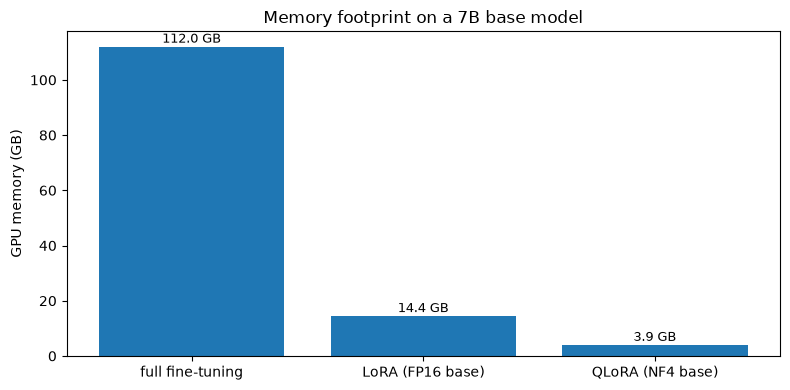

In [29]:
# === 可视化：三种方案的显存对比 ===
names = [name for name, _ in rows]
gbs = [b / 1e9 for _, b in rows]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, gbs)
for bar, gb in zip(bars, gbs):
    plt.text(bar.get_x() + bar.get_width() / 2, gb + 1.5,
             f"{gb:.1f} GB", ha="center", fontsize=9)
plt.ylabel("GPU memory (GB)")
plt.title("Memory footprint on a 7B base model")
plt.tight_layout()
plt.show()


### 超参速查

| 问题 | 常见做法 |
|:--|:--|
| 秩 r | 8 或 16 起步；任务复杂、数据多再上 32、64 |
| alpha | 常取 r 的 2 倍；调 r 时固定 alpha，实际缩放 alpha/r 会随 r 变化 |
| 挂哪些层 | 学习类任务 all-linear 稳妥；原论文的 q,v 配置常作 baseline |
| 学习率 | 1e-4 到 3e-4 量级，比全量微调高一个数量级 |
| dropout | 原论文设 0.05 到 0.25 防小数据过拟合；数据充足时常设 0 |
| 训练轮数 | 小数据集几十个 epoch 很常见，盯验证集早停 |

学习率为什么能比全量微调大？全量微调节奏快了会破坏预训练权重；LoRA 的基座被冻结，出问题的范围被限制在旁路的小矩阵里，大步长反而帮低容量旁路尽快收敛。

需要注意：LoRA 的可学习容量小于全量微调。数据量大、任务和基座分布差异大的场景（比如继续预训练学一门新语言），全量微调仍占优；「LoRA 学得少、忘得也少」是文献里反复出现的观察（LoRA Learns Less and Forgets Less, 2024）。两种方案先用小规模数据对比，再决定用哪种。

## 小结（checklist）

1. ✅ 微调学的是 ΔW = W1 - W0；低秩意味着 ΔW ≈ BA，只需 r×(d_in+d_out) 个参数
2. ✅ 全量微调每参数 16 bytes（权重+梯度+优化器状态）；LoRA 冻结基座后，这部分开销只落在 adapter 上
3. ✅ A 随机初始化、B 全零初始化：初始输出与基座相同，梯度也不会死锁
4. ✅ LoraLinear 与 nn.Linear 接口一致，注入只是模块替换；注入后必须冻结其余全部参数
5. ✅ dense 实验：两种 LoRA 都把 loss 拉到远低于冻结基座；all-linear 逼近全量微调，挂的层越多改动能力越强
6. ✅ 合并 W' = W0 + (alpha/r)·BA 后，模型结构与原基座相同，推理零额外开销
7. ✅ MoE 的参数大头在专家（本章迷你模型约九成），LoRA 的显存收益比 dense 更大
8. ✅ MoE 挂 LoRA：attention 和专家可以挂，gate 不挂；每个专家各配一对 A、B
9. ✅ gate 不挂 LoRA：训练后 gate 权重逐位不变，打分规则保持冻结（上游表示变了，路由仍可能轻微移动）
10. ✅ checkpoint 只存 A、B；一个基座配多个任务适配器，可以合并部署也可以运行时切换
11. ✅ QLoRA = LoRA + NF4 量化基座，7B 训练显存从约 112 GB 降到约 4 GB
12. ✅ LoRA 学习率比全量微调高一个数量级；容量小于全量微调，分布差异大的任务要先对比验证

**一句话总结**：LoRA 把微调重新参数化成「在冻结的基座旁边学一对小矩阵」。dense 和 MoE 用的是同一套机制，区别只在挂哪些层——专家存着知识，要挂；gate 管路由分配，不能动。

## 作业

> 可以让 AI 帮忙解释思路、拆步骤、检查方向，但不建议直接让 AI「做完这道题」。

**作业 1：LoRA 参数量**

一个线性层 $d_{out} = 4096$、$d_{in} = 4096$，挂秩 $r = 16$ 的 LoRA。计算：原始权重的参数量、LoRA 新增的参数量（A+B）、新增量占原始参数量的比例。

小提示：LoRA 参数 = $r \times d_{in} + d_{out} \times r$。

In [30]:
# 作业 1：LoRA 参数量
d_out, d_in = 4096, 4096
r = 16

# TODO: 原始权重的参数量
original_params = None

# TODO: LoRA 新增的参数量（A + B）
lora_params = None

# TODO: 新增量占原始参数量的比例
ratio = None

# 填完后取消下面的注释运行检查
# assert original_params == d_out * d_in
# assert lora_params == r * d_in + d_out * r
# assert abs(ratio - lora_params / original_params) < 1e-9
# print(f"✅ 作业 1 通过：原始 {original_params:,}，LoRA 新增 {lora_params:,}，占 {ratio:.2%}")
# print("   一个 16M 参数的矩阵，旁路只需要 13 万参数。")

**作业 2：手算权重合并**

$$W_0 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix},\quad
B = \begin{pmatrix} 0.6 \\ 0.2 \end{pmatrix},\quad
A = \begin{pmatrix} 0.5 & -1.0 \end{pmatrix},\quad \alpha / r = 1$$

计算合并后的权重 $W' = W_0 + \frac{\alpha}{r} BA$。

小提示：$BA$ 是外积，$2 \times 1$ 乘 $1 \times 2$ 得到 $2 \times 2$。

In [31]:
# 作业 2：手算权重合并
import torch

W0 = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
B = torch.tensor([[0.6], [0.2]])
A = torch.tensor([[0.5, -1.0]])
scaling = 1.0

# TODO: 先算 delta = B @ A，再算 W_merged = W0 + scaling * delta
W_merged = None

# 填完后取消下面的注释运行检查
# expected = W0 + scaling * (B @ A)
# assert torch.allclose(W_merged, expected, atol=1e-6)
# print(f"✅ 作业 2 通过：W' = {W_merged.tolist()}")
# print("   合并后的形状与 W0 相同，推理时就是一次普通矩阵乘法。")

**作业 3：给 MoE 的专家挂 LoRA，参数量多几倍**

一个 Mixtral 风格的 MoE 层：8 个专家，每个专家的 `w_up` 是 $14336 \times 4096$ 的矩阵；同一个模型里 Attention 的 `W_Q` 是 $4096 \times 4096$。都挂 $r = 16$ 的 LoRA，计算：8 个专家全部 `w_up` 的 LoRA 总参数量、单独给 `W_Q` 挂的参数量、前者是后者的几倍。

小提示：单个矩阵的 LoRA 参数 = $r \times (d_{in} + d_{out})$；专家数只影响「有几份」。

In [32]:
# 作业 3：MoE 专家的 LoRA 参数量
num_experts = 8
d_model = 4096
expert_dim = 14336
r = 16

# TODO: 8 个专家全部 w_up 的 LoRA 总参数量
experts_lora_params = None

# TODO: 单独给 W_Q 挂 LoRA 的参数量
attn_lora_params = None

# TODO: 前者是后者的几倍
times = None

# 填完后取消下面的注释运行检查
# assert experts_lora_params == num_experts * r * (d_model + expert_dim)
# assert attn_lora_params == r * (d_model + d_model)
# assert abs(times - experts_lora_params / attn_lora_params) < 1e-9
# print(f"✅ 作业 3 通过：专家 {experts_lora_params:,}，W_Q {attn_lora_params:,}，{times:.0f} 倍")
# print("   专家的矩阵更宽，数量又多，adapter 开销主要花在专家上。")

## 参考资料

- Hu et al., [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685), 2021 — LoRA 原始论文
- Aghajanyan et al., [Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning](https://arxiv.org/abs/2012.13255), 2020 — 「微调只需要低维子空间」的实证起点
- Dettmers et al., [QLoRA: Efficient Finetuning of Quantized LLMs](https://arxiv.org/abs/2305.14314), 2023 — NF4 量化基座 + LoRA
- Biderman et al., [LoRA Learns Less and Forgets Less](https://arxiv.org/abs/2405.09673), 2024 — LoRA 与全量微调的容量对比
- Liu et al., [DoRA: Weight-Decomposed Low-Rank Adaptation](https://arxiv.org/abs/2402.09353), 2024 — 把权重拆成幅度和方向，再做低秩适配